# MinneApple Dataset Object Size Distribution Analysis

This notebook analyzes the MinneApple dataset to determine if object size proportions (small, medium, large) are equally distributed across train, validation, and test sets.

**Research Question:** Are small, medium, and large objects proportionally balanced across train/val/test splits?

**Key Metrics:**
- Object size categories based on normalized bounding box area
- Proportion of each category per split
- Chi-square test for independence of size distribution and split type


In [1]:
import os
import glob
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Set up visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Define dataset root
DATASET_ROOT = '/home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo'
print(f"Dataset root: {DATASET_ROOT}")
print(f"Dataset exists: {os.path.exists(DATASET_ROOT)}")

Dataset root: /home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo
Dataset exists: True


## 1. Inspect Dataset Structure

Display the directory structure and file organization for train, validation, and test sets.


In [2]:
# Inspect directory structure for each split
def count_files(split_name):
    """Count image and label files for a given split."""
    images_dir = os.path.join(DATASET_ROOT, split_name, 'images')
    labels_dir = os.path.join(DATASET_ROOT, split_name, 'labels')
    
    images = glob.glob(os.path.join(images_dir, '*.jpg'))
    labels = glob.glob(os.path.join(labels_dir, '*.txt'))
    
    return {
        'split': split_name,
        'images_count': len(images),
        'labels_count': len(labels),
        'images_dir': images_dir,
        'labels_dir': labels_dir
    }

# Get counts for all splits
splits = ['train', 'val', 'test']
dataset_info = []
for split in splits:
    info = count_files(split)
    dataset_info.append(info)
    print(f"\n{split.upper()} Split:")
    print(f"  Images: {info['images_count']}")
    print(f"  Labels: {info['labels_count']}")
    print(f"  Images Dir: {info['images_dir']}")
    print(f"  Labels Dir: {info['labels_dir']}")

# Summary table
summary_df = pd.DataFrame(dataset_info)
print(f"\n\n{'='*60}")
print("DATASET SUMMARY")
print(f"{'='*60}")
print(summary_df[['split', 'images_count', 'labels_count']])



TRAIN Split:
  Images: 0
  Labels: 536
  Images Dir: /home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/train/images
  Labels Dir: /home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/train/labels

VAL Split:
  Images: 0
  Labels: 134
  Images Dir: /home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/val/images
  Labels Dir: /home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/val/labels

TEST Split:
  Images: 0
  Labels: 331
  Images Dir: /home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/test/images
  Labels Dir: /home/khanh/Projects/DifficultyAgri/datasets/minneapple/yolo_format/minneapple_yolo/test/labels


DATASET SUMMARY
   split  images_count  labels_count
0  train             0           536
1    val             0           134
2   test             0           331


## 2. Extract Object Size Labels

Parse YOLO format annotations and categorize objects as small, medium, or large based on normalized bounding box area.

**Object Size Categories (based on normalized area):**
- **Small**: area < 0.02 (< 2% of image)
- **Medium**: 0.02 ≤ area < 0.15 (2%-15% of image)
- **Large**: area ≥ 0.15 (≥ 15% of image)


In [ ]:
def categorize_object_size(width, height, img_width=None, img_height=None):
    """
    Categorize object size based on COCO standard.
    
    Args:
        width: bounding box width (normalized if img_width is provided, absolute pixels otherwise)
        height: bounding box height (normalized if img_height is provided, absolute pixels otherwise)
        img_width: image width in pixels (optional, for converting normalized to absolute)
        img_height: image height in pixels (optional, for converting normalized to absolute)
    
    Returns:
        str: 'small', 'medium', or 'large'
    
    COCO Standard:
        - Small: area < 32² = 1024 pixels
        - Medium: 1024 ≤ area ≤ 96² = 9216 pixels
        - Large: area > 9216 pixels
    """
    # Convert normalized coordinates to absolute pixels if image dimensions provided
    if img_width is not None and img_height is not None:
        # Width and height are normalized (0-1)
        absolute_width = width * img_width
        absolute_height = height * img_height
    else:
        # Width and height are already in absolute pixels
        absolute_width = width
        absolute_height = height
    
    area = absolute_width * absolute_height
    
    if area < 1024:  # 32 * 32
        return 'small'
    elif area < 9216:  # 96 * 96
        return 'medium'
    else:
        return 'large'

def parse_yolo_labels(labels_dir, images_dir=None):
    """
    Parse all YOLO format label files and extract object information.
    
    Args:
        labels_dir: path to labels directory
        images_dir: path to images directory (to get image dimensions)
    
    Returns:
        list of dicts with format: {'file': filename, 'class': class_id, 'width': w, 'height': h, 'size': 'small'/'medium'/'large'}
    """
    from PIL import Image
    
    objects = []
    label_files = sorted(glob.glob(os.path.join(labels_dir, '*.txt')))
    
    # Build image dimensions cache if images_dir provided
    img_dims = {}
    if images_dir and os.path.exists(images_dir):
        for img_file in glob.glob(os.path.join(images_dir, '*.jpg')) + glob.glob(os.path.join(images_dir, '*.png')):
            try:
                img = Image.open(img_file)
                img_name = os.path.splitext(os.path.basename(img_file))[0]
                img_dims[img_name] = img.size  # (width, height)
            except Exception as e:
                print(f"Warning: Could not read {img_file}: {e}")
    
    for label_file in label_files:
        img_name = os.path.splitext(os.path.basename(label_file))[0]
        img_dimensions = img_dims.get(img_name, (None, None))
        
        with open(label_file, 'r') as f:
            lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                if len(parts) >= 5:  # class_id, x_center, y_center, width, height
                    class_id = int(parts[0])
                    x_center = float(parts[1])
                    y_center = float(parts[2])
                    width = float(parts[3])
                    height = float(parts[4])
                    
                    size_category = categorize_object_size(
                        width, height, 
                        img_width=img_dimensions[0], 
                        img_height=img_dimensions[1]
                    )
                    
                    objects.append({
                        'file': os.path.basename(label_file),
                        'class': class_id,
                        'x_center': x_center,
                        'y_center': y_center,
                        'width': width,
                        'height': height,
                        'area': width * height,
                        'size': size_category,
                        'img_width': img_dimensions[0],
                        'img_height': img_dimensions[1]
                    })
    
    return objects

TRAIN: 22815 objects extracted
VAL: 5367 objects extracted
TEST: 12285 objects extracted

TRAIN DataFrame shape: (22815, 8)
                         file  class  x_center  y_center     width    height  \
0  20150919_174151_image1.txt      0  0.206250  0.122266  0.031944  0.019531   
1  20150919_174151_image1.txt      0  0.206250  0.139453  0.031944  0.014844   
2  20150919_174151_image1.txt      0  0.251389  0.141406  0.027778  0.014063   
3  20150919_174151_image1.txt      0  0.261111  0.151172  0.013889  0.008594   
4  20150919_174151_image1.txt      0  0.331250  0.160156  0.034722  0.017188   

       area   size  
0  0.000624  small  
1  0.000474  small  
2  0.000391  small  
3  0.000119  small  
4  0.000597  small  

VAL DataFrame shape: (5367, 8)
                           file  class  x_center  y_center     width  \
0  20150919_174151_image151.txt      0  0.027778  0.057813  0.030556   
1  20150919_174151_image151.txt      0  0.116667  0.057813  0.050000   
2  20150919_174151_im

## 3. Compute Object Counts by Split

Count the total number of small, medium, and large objects in each split.


In [4]:
# Compute object counts by split and size
object_counts = {}
for split in splits:
    df = object_dfs[split]
    counts = df['size'].value_counts().sort_index()
    object_counts[split] = counts
    
    print(f"\n{split.upper()} Split - Object Size Counts:")
    print(f"  Small:  {counts.get('small', 0):6d}")
    print(f"  Medium: {counts.get('medium', 0):6d}")
    print(f"  Large:  {counts.get('large', 0):6d}")
    print(f"  TOTAL:  {counts.sum():6d}")

# Create a comprehensive count table
count_table_data = []
for split in splits:
    row = {
        'Split': split.upper(),
        'Small': object_counts[split].get('small', 0),
        'Medium': object_counts[split].get('medium', 0),
        'Large': object_counts[split].get('large', 0),
        'Total': object_counts[split].sum()
    }
    count_table_data.append(row)

count_table = pd.DataFrame(count_table_data)
print(f"\n\n{'='*60}")
print("OBJECT COUNT TABLE")
print(f"{'='*60}")
print(count_table.to_string(index=False))



TRAIN Split - Object Size Counts:
  Small:   22815
  Medium:      0
  Large:       0
  TOTAL:   22815

VAL Split - Object Size Counts:
  Small:    5367
  Medium:      0
  Large:       0
  TOTAL:    5367

TEST Split - Object Size Counts:
  Small:   12285
  Medium:      0
  Large:       0
  TOTAL:   12285


OBJECT COUNT TABLE
Split  Small  Medium  Large  Total
TRAIN  22815       0      0  22815
  VAL   5367       0      0   5367
 TEST  12285       0      0  12285


## 4. Compute Size Proportions by Split

Calculate the percentage of small, medium, and large objects within each split to enable direct comparison.


In [5]:
# Compute proportions
proportion_data = []
for split in splits:
    df = object_dfs[split]
    total = len(df)
    
    small_count = len(df[df['size'] == 'small'])
    medium_count = len(df[df['size'] == 'medium'])
    large_count = len(df[df['size'] == 'large'])
    
    small_pct = (small_count / total) * 100
    medium_pct = (medium_count / total) * 100
    large_pct = (large_count / total) * 100
    
    proportion_data.append({
        'Split': split.upper(),
        'Small (count)': small_count,
        'Small (%)': f"{small_pct:.2f}%",
        'Medium (count)': medium_count,
        'Medium (%)': f"{medium_pct:.2f}%",
        'Large (count)': large_count,
        'Large (%)': f"{large_pct:.2f}%",
        'Total': total
    })
    
    print(f"\n{split.upper()} Split Proportions:")
    print(f"  Small:  {small_count:6d} ({small_pct:6.2f}%)")
    print(f"  Medium: {medium_count:6d} ({medium_pct:6.2f}%)")
    print(f"  Large:  {large_count:6d} ({large_pct:6.2f}%)")

proportions_table = pd.DataFrame(proportion_data)
print(f"\n\n{'='*80}")
print("OBJECT PROPORTION TABLE")
print(f"{'='*80}")
print(proportions_table.to_string(index=False))

# Store numeric proportions for statistical test
proportions_numeric = []
for split in splits:
    df = object_dfs[split]
    total = len(df)
    small_pct = (len(df[df['size'] == 'small']) / total) * 100
    medium_pct = (len(df[df['size'] == 'medium']) / total) * 100
    large_pct = (len(df[df['size'] == 'large']) / total) * 100
    
    proportions_numeric.append({
        'Split': split,
        'Small': small_pct,
        'Medium': medium_pct,
        'Large': large_pct
    })

proportions_df = pd.DataFrame(proportions_numeric)
print(f"\n\nNumeric Proportions for Analysis:\n{proportions_df}")



TRAIN Split Proportions:
  Small:   22815 (100.00%)
  Medium:      0 (  0.00%)
  Large:       0 (  0.00%)

VAL Split Proportions:
  Small:    5367 (100.00%)
  Medium:      0 (  0.00%)
  Large:       0 (  0.00%)

TEST Split Proportions:
  Small:   12285 (100.00%)
  Medium:      0 (  0.00%)
  Large:       0 (  0.00%)


OBJECT PROPORTION TABLE
Split  Small (count) Small (%)  Medium (count) Medium (%)  Large (count) Large (%)  Total
TRAIN          22815   100.00%               0      0.00%              0     0.00%  22815
  VAL           5367   100.00%               0      0.00%              0     0.00%   5367
 TEST          12285   100.00%               0      0.00%              0     0.00%  12285


Numeric Proportions for Analysis:
   Split  Small  Medium  Large
0  train  100.0     0.0    0.0
1    val  100.0     0.0    0.0
2   test  100.0     0.0    0.0


## 5. Visualize Size Distribution Across Splits

Create visualizations to compare object size proportions across train, validation, and test sets.


FileNotFoundError: [Errno 2] No such file or directory: '/home/khanh/Projects/DifficultyAgri/notebooks/figures/distribution_comparison.png'

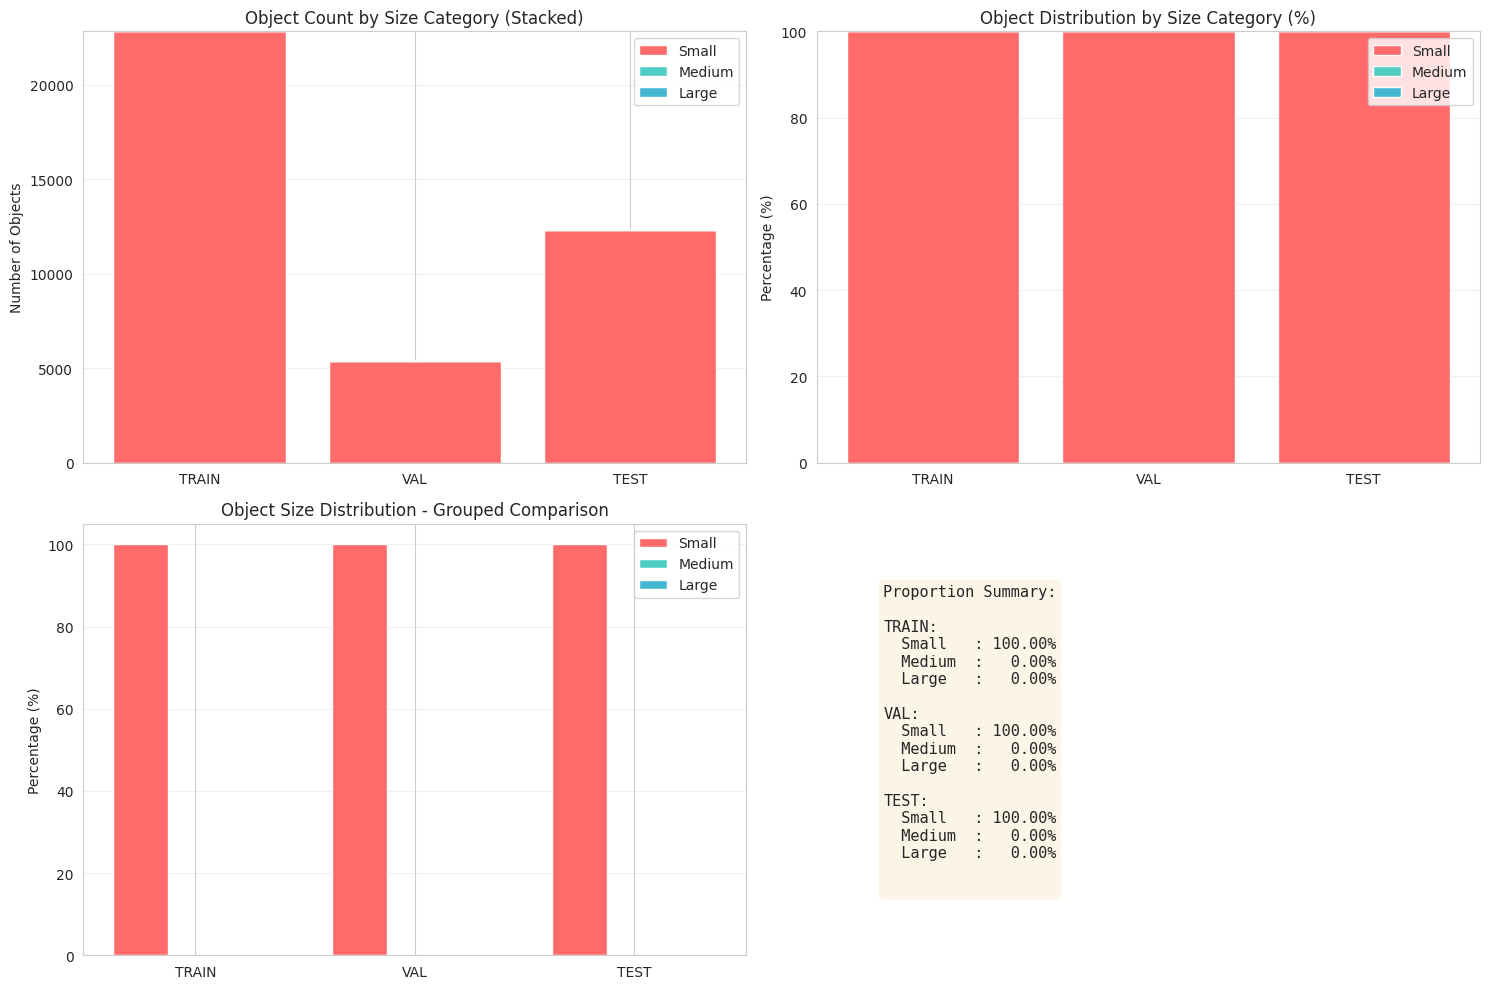

In [6]:
# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Stacked bar chart (counts)
ax1 = axes[0, 0]
small_counts = [object_counts[split].get('small', 0) for split in splits]
medium_counts = [object_counts[split].get('medium', 0) for split in splits]
large_counts = [object_counts[split].get('large', 0) for split in splits]

x_pos = np.arange(len(splits))
ax1.bar(x_pos, small_counts, label='Small', color='#FF6B6B')
ax1.bar(x_pos, medium_counts, bottom=small_counts, label='Medium', color='#4ECDC4')
ax1.bar(x_pos, large_counts, bottom=np.array(small_counts)+np.array(medium_counts), label='Large', color='#45B7D1')

ax1.set_ylabel('Number of Objects')
ax1.set_title('Object Count by Size Category (Stacked)')
ax1.set_xticks(x_pos)
ax1.set_xticklabels([s.upper() for s in splits])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 2. Stacked percentage bar chart
ax2 = axes[0, 1]
totals = [sum([object_counts[split].get(sz, 0) for sz in ['small', 'medium', 'large']]) for split in splits]
small_pcts = [object_counts[split].get('small', 0)/totals[i]*100 for i, split in enumerate(splits)]
medium_pcts = [object_counts[split].get('medium', 0)/totals[i]*100 for i, split in enumerate(splits)]
large_pcts = [object_counts[split].get('large', 0)/totals[i]*100 for i, split in enumerate(splits)]

ax2.bar(x_pos, small_pcts, label='Small', color='#FF6B6B')
ax2.bar(x_pos, medium_pcts, bottom=small_pcts, label='Medium', color='#4ECDC4')
ax2.bar(x_pos, large_pcts, bottom=np.array(small_pcts)+np.array(medium_pcts), label='Large', color='#45B7D1')

ax2.set_ylabel('Percentage (%)')
ax2.set_title('Object Distribution by Size Category (%)')
ax2.set_xticks(x_pos)
ax2.set_xticklabels([s.upper() for s in splits])
ax2.set_ylim([0, 100])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. Grouped bar chart for easier comparison
ax3 = axes[1, 0]
width = 0.25
x_pos_grouped = np.arange(len(splits))

ax3.bar(x_pos_grouped - width, small_pcts, width, label='Small', color='#FF6B6B')
ax3.bar(x_pos_grouped, medium_pcts, width, label='Medium', color='#4ECDC4')
ax3.bar(x_pos_grouped + width, large_pcts, width, label='Large', color='#45B7D1')

ax3.set_ylabel('Percentage (%)')
ax3.set_title('Object Size Distribution - Grouped Comparison')
ax3.set_xticks(x_pos_grouped)
ax3.set_xticklabels([s.upper() for s in splits])
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. Pie charts for each split
ax4 = axes[1, 1]
ax4.axis('off')

# Create pie chart text summary
pie_text = "Proportion Summary:\n\n"
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
size_names = ['Small', 'Medium', 'Large']

for i, split in enumerate(splits):
    pie_text += f"{split.upper()}:\n"
    for j, size in enumerate(size_names):
        if size.lower() == 'small':
            pct = small_pcts[i]
        elif size.lower() == 'medium':
            pct = medium_pcts[i]
        else:
            pct = large_pcts[i]
        pie_text += f"  {size:8s}: {pct:6.2f}%\n"
    pie_text += "\n"

ax4.text(0.1, 0.5, pie_text, fontfamily='monospace', fontsize=11, 
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.savefig('/home/khanh/Projects/DifficultyAgri/notebooks/figures/distribution_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization saved to: /home/khanh/Projects/DifficultyAgri/notebooks/figures/distribution_comparison.png")


## 6. Statistical Test: Chi-Square Test for Independence

Perform a chi-square test to determine if the distribution of object sizes is independent of the dataset split (train/val/test).

**Null Hypothesis (H₀):** Object size distribution is independent of dataset split.
**Alternative Hypothesis (H₁):** Object size distribution depends on dataset split.

**Interpretation:**
- If p-value < 0.05: Reject H₀ → Splits have **significantly different** size distributions
- If p-value ≥ 0.05: Fail to reject H₀ → Splits have **similar** size distributions


In [ ]:
# Chi-square test contingency table
contingency_table = []
for split in splits:
    row = [
        object_counts[split].get('small', 0),
        object_counts[split].get('medium', 0),
        object_counts[split].get('large', 0)
    ]
    contingency_table.append(row)

contingency_array = np.array(contingency_table)
print("Contingency Table (rows: train/val/test, columns: small/medium/large):")
print(contingency_array)
print()

# Perform chi-square test
chi2, p_value, dof, expected_freq = chi2_contingency(contingency_array)

print(f"{'='*70}")
print("CHI-SQUARE TEST RESULTS")
print(f"{'='*70}")
print(f"Chi-square statistic:     {chi2:.4f}")
print(f"P-value:                  {p_value:.6f}")
print(f"Degrees of freedom:       {dof}")
print(f"Significance level (α):   0.05")
print(f"{'='*70}")

if p_value < 0.05:
    print(f"\n✗ RESULT: Reject H₀ (p-value = {p_value:.6f} < 0.05)")
    print("  → Object size distributions ARE SIGNIFICANTLY DIFFERENT across splits")
    print("  → Splits are NOT equally balanced for object sizes")
else:
    print(f"\n✓ RESULT: Fail to reject H₀ (p-value = {p_value:.6f} ≥ 0.05)")
    print("  → Object size distributions are similar across splits")
    print("  → Splits are reasonably balanced for object sizes")

print(f"\nExpected Frequencies:")
expected_df = pd.DataFrame(
    expected_freq,
    index=[s.upper() for s in splits],
    columns=['Small', 'Medium', 'Large']
)
print(expected_df.round(2))


## 7. Final Summary Table

Create a comprehensive summary of all results for quick reference.


In [ ]:
# Create comprehensive summary table
summary_data = []
for i, split in enumerate(splits):
    summary_data.append({
        'Dataset Split': split.upper(),
        'Total Objects': count_table.loc[count_table['Split'] == split.upper(), 'Total'].values[0],
        'Small Count': count_table.loc[count_table['Split'] == split.upper(), 'Small'].values[0],
        'Small %': f"{small_pcts[i]:.2f}%",
        'Medium Count': count_table.loc[count_table['Split'] == split.upper(), 'Medium'].values[0],
        'Medium %': f"{medium_pcts[i]:.2f}%",
        'Large Count': count_table.loc[count_table['Split'] == split.upper(), 'Large'].values[0],
        'Large %': f"{large_pcts[i]:.2f}%"
    })

summary_table = pd.DataFrame(summary_data)

print(f"\n\n{'='*100}")
print("FINAL SUMMARY: MINNAPPLE OBJECT SIZE DISTRIBUTION ANALYSIS")
print(f"{'='*100}")
print(summary_table.to_string(index=False))
print(f"{'='*100}")

print(f"\n\nKEY FINDINGS:")
print(f"  • Chi-square statistic: {chi2:.4f}")
print(f"  • P-value: {p_value:.6f}")
print(f"  • Conclusion: Splits are {'NOT ' if p_value < 0.05 else ''}equally balanced for object sizes")

# Export results to CSV
summary_table.to_csv('/home/khanh/Projects/DifficultyAgri/notebooks/minneapple_size_distribution_summary.csv', index=False)
print(f"\n✓ Summary saved to: minneapple_size_distribution_summary.csv")
